In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [16]:
pd.options.display.max_rows = 150

In [2]:
diseaseDF = pd.read_csv('U.S._Chronic_Disease_Indicators.csv', delimiter=",", encoding='utf-8')

In [3]:
diseaseDF

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,Geolocation,LocationID,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,2.9,2.9,NaN,NaN,2.8,2.9,Sex,Female,NaN,NaN,NaN,NaN,NaN,59,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,9537.0,9537.0,NaN,NaN,NaN,NaN,Sex,Male,NaN,NaN,NaN,NaN,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,486.0,486.0,NaN,NaN,NaN,NaN,Overall,Overall,NaN,NaN,NaN,NaN,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,2880.0,2880.0,NaN,NaN,NaN,NaN,Race/Ethnicity,Hispanic,NaN,NaN,NaN,NaN,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,519.0,519.0,NaN,NaN,NaN,NaN,Race/Ethnicity,"White, non-Hispanic",NaN,NaN,NaN,NaN,POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309210,2022,2022,VI,Virgin Islands,BRFSS,Tobacco,Quit attempts in the past year among adult cur...,NaN,%,Age-adjusted Prevalence,NaN,NaN,#,No data available for this indicator because t...,NaN,NaN,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",NaN,NaN,NaN,NaN,POINT (-64.896335 18.335765),78,TOB,TOB06,NaN,AGEADJPREV,RACE,AIAN,NaN,NaN,NaN,NaN
309211,2022,2022,WV,West Virginia,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,NaN,%,Crude Prevalence,14.0,14.0,NaN,NaN,12.8,15.2,Overall,Overall,NaN,NaN,NaN,NaN,POINT (-80.71264013499967 38.66551020200046),54,COPD,COPD01,NaN,CRDPREV,OVERALL,OVR,NaN,NaN,NaN,NaN
309212,2022,2022,WI,Wisconsin,BRFSS,Immunization,Pneumococcal vaccination among adults aged 65 ...,NaN,%,Crude Prevalence,64.2,64.2,NaN,NaN,52.2,74.6,Race/Ethnicity,"Black, non-Hispanic",NaN,NaN,NaN,NaN,POINT (-89.81637074199966 44.39319117400049),55,IMM,IMM04,NaN,CRDPREV,RACE,BLK,NaN,NaN,NaN,NaN
309213,2022,2022,VT,Vermont,BRFSS,Social Determinants of Health,Lack of health insurance among adults aged 18-...,NaN,%,Crude Prevalence,NaN,NaN,****,Data suppressed; denominator < 50 or relative ...,NaN,NaN,Race/Ethnicity,"Hawaiian or Pacific Islander, non-Hispanic",NaN,NaN,NaN,NaN,POINT (-72.51764079099962 43.62538123900049),50,SDOH,SDH09,NaN,CRDPREV,RACE,HAPI,NaN,NaN,NaN,NaN


In [4]:
diseaseDF = diseaseDF.drop(columns = ['Response', 'DataValueFootnoteSymbol', 'DataValueFootnote',\
'StratificationCategory2', 'Stratification2','StratificationCategory3', 'Stratification3',\
'ResponseID', 'StratificationCategoryID2', 'StratificationID2', 'StratificationCategoryID3', 'StratificationID3'])

In [33]:
cancerDF = diseaseDF[(diseaseDF['Question'].str.contains('Prostate')) & (diseaseDF['YearStart'] == 2015) &\
    (diseaseDF['Stratification1'] == 'Overall') & (diseaseDF['DataValueType'] == 'Crude Rate')]
cancerDF

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,DataValueAlt,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
10,2015,2019,SD,South Dakota,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,20.2,20.2,18.4,22.2,Overall,Overall,POINT (-100.3735306369997 44.353130053000484),46,CAN,CAN05,CRDRATE,OVERALL,OVR
13,2015,2019,VT,Vermont,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,23.0,23.0,20.7,25.5,Overall,Overall,POINT (-72.51764079099962 43.62538123900049),50,CAN,CAN05,CRDRATE,OVERALL,OVR
1113,2015,2019,ND,North Dakota,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,18.4,18.4,16.5,20.4,Overall,Overall,POINT (-100.11842104899966 47.47531977900047),38,CAN,CAN05,CRDRATE,OVERALL,OVR
1871,2015,2019,IL,Illinois,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,19.4,19.4,18.9,19.9,Overall,Overall,POINT (-88.99771017799969 40.48501028300046),17,CAN,CAN05,CRDRATE,OVERALL,OVR
1881,2015,2019,ID,Idaho,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,21.5,21.5,20.2,22.9,Overall,Overall,POINT (-114.3637300419997 43.682630005000476),16,CAN,CAN05,CRDRATE,OVERALL,OVR
2025,2015,2019,MI,Michigan,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,19.8,19.8,19.3,20.4,Overall,Overall,POINT (-84.71439026999968 44.6613195430005),26,CAN,CAN05,CRDRATE,OVERALL,OVR
2297,2015,2019,LA,Louisiana,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,18.9,18.9,18.1,19.7,Overall,Overall,POINT (-92.44568007099969 31.31266064400046),22,CAN,CAN05,CRDRATE,OVERALL,OVR
3114,2015,2019,WI,Wisconsin,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,22.1,22.1,21.4,22.9,Overall,Overall,POINT (-89.81637074199966 44.39319117400049),55,CAN,CAN05,CRDRATE,OVERALL,OVR
3120,2015,2019,MS,Mississippi,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,23.8,23.8,22.7,24.9,Overall,Overall,POINT (-89.53803082499968 32.745510099000455),28,CAN,CAN05,CRDRATE,OVERALL,OVR
3419,2015,2019,FL,Florida,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,22.9,22.9,22.5,23.4,Overall,Overall,POINT (-81.92896053899966 28.932040377000476),12,CAN,CAN05,CRDRATE,OVERALL,OVR


<Axes: >

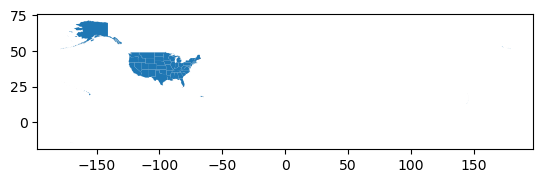

In [43]:
url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip"
USMap = gpd.read_file(url)
USMap.plot()